## Ecocondução, Hábitos e Eficiência de Combustível: Uma Análise Exploratória

### 1. Contextualização

A ecocondução é um conjunto de comportamentos e hábitos de condução adotados com o objetivo de reduzir o consumo de combustível e aumentar a eficiência energética dos veículos. Este dataset reúne métricas relacionadas a diferentes padrões de condução, bem como uma pontuação final que representa o nível de eficiência em ecocondução de cada motorista.

#### 1.1 Metas e objetivos

O objetivo deste projeto é analisar as correlações entre as variáveis, desenvolver visualizações por meio da Análise Exploratória de Dados (EDA) e identificar, classificar e comparar diferentes categorias de motoristas com base em seus comportamentos de condução.

#### 1.2 Estrutura do dataset

| Coluna                  | Descrição                                                |
|-------------------------|----------------------------------------------------------|
| rpm_variation           | Grau de variação da rotação do motor durante a condução. |
| harsh_braking_count     | Número de eventos de frenagem brusca.                    |
| idling_time             | Tempo total com o veículo em marcha lenta.               |
| fuel_consumption        | Consumo de combustível no período analisado.             |
| acceleration_smoothness | Nível de suavidade nas acelerações do veículo.           |
| eco_score               | Pontuação de eficiência da condução (0 a 100).           |

### 2. Preparação do ambiente

#### 2.1 Requisitos

In [69]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Configuração do matplotlib
plt.style.use('ggplot')

#### 2.2 Carregamento dos dados

In [70]:
df = pd.read_csv('eco_driving_score.csv')

### 3. Qualidade dos dados

In [71]:
print(
f"""
Dataset
Linhas: {df.shape[0]}
Colunas: {df.shape[1]}

Todos as colunas desse dataset são de dados numéricos.
""")


Dataset
Linhas: 30000
Colunas: 6

Todos as colunas desse dataset são de dados numéricos.



In [72]:
print("Número de valores faltando ou NaN")
df.isnull().sum()

Número de valores faltando ou NaN


rpm_variation              0
harsh_braking_count        0
idling_time                0
fuel_consumption           0
acceleration_smoothness    0
eco_score                  0
dtype: int64

In [73]:
df.head()

,rpm_variation,harsh_braking_count,idling_time,fuel_consumption,acceleration_smoothness,eco_score
0,2147,5,14.2,7.87,0.97,42.1
1,1703,3,4.2,9.37,0.50,36.1
2,2253,0,5.5,8.85,0.78,49.8
3,2866,3,21.7,5.87,0.60,27.7
4,1636,2,3.1,6.71,0.99,79.4


In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   rpm_variation            30000 non-null  int64  
 1   harsh_braking_count      30000 non-null  int64  
 2   idling_time              30000 non-null  float64
 3   fuel_consumption         30000 non-null  float64
 4   acceleration_smoothness  30000 non-null  float64
 5   eco_score                30000 non-null  float64
dtypes: float64(4), int64(2)
memory usage: 1.4 MB


In [75]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
print("Número de outliers em cada coluna: ")
((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).sum()

Número de outliers em cada coluna: 


rpm_variation              100
harsh_braking_count        229
idling_time                112
fuel_consumption           241
acceleration_smoothness    110
eco_score                    0
dtype: int64

No pior dos casos, o número de outliers é apenas 0,8% dos dados, então não serão utilizadas medidas robustas como média truncada.

In [76]:
df.describe().round(3)

,rpm_variation,harsh_braking_count,idling_time,fuel_consumption,acceleration_smoothness,eco_score
count,30000.000,30000.000,30000.000,30000.000,30000.000,30000.000
mean,1807.951,2.726,11.282,8.052,0.668,47.489
std,679.424,1.671,5.294,1.513,0.155,19.462
min,500.000,0.000,0.000,3.500,0.030,0.000
25%,1325.000,2.000,7.600,7.030,0.560,34.600
50%,1801.000,3.000,11.200,8.040,0.670,48.400
75%,2272.000,4.000,14.900,9.050,0.780,61.300
max,4935.000,14.000,32.500,14.430,1.000,100.000


### 4. Análise Exploratória de Dados

#### 4.1 Correlação entre as variáveis

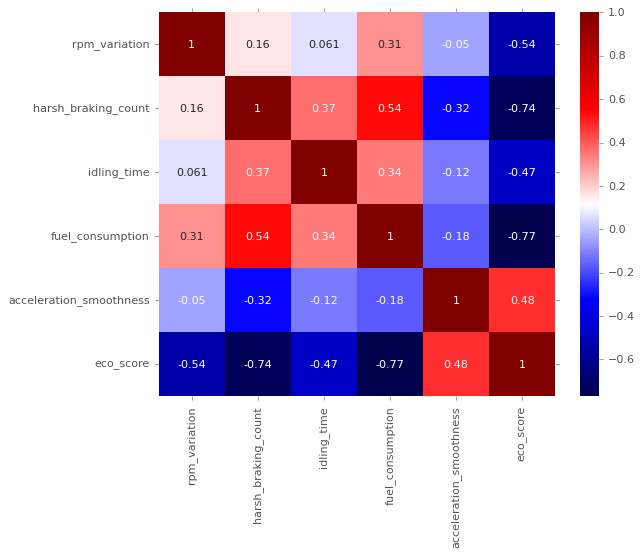

In [77]:
sns.heatmap(df.corr(), annot=True, cmap='seismic')
plt.show()

In [78]:
eco_score_correlation = df.corr()['eco_score'].sort_values(ascending=False)
eco_score_correlation

eco_score                  1.000000
acceleration_smoothness    0.481003
idling_time               -0.468010
rpm_variation             -0.537513
harsh_braking_count       -0.742530
fuel_consumption          -0.770575
Name: eco_score, dtype: float64

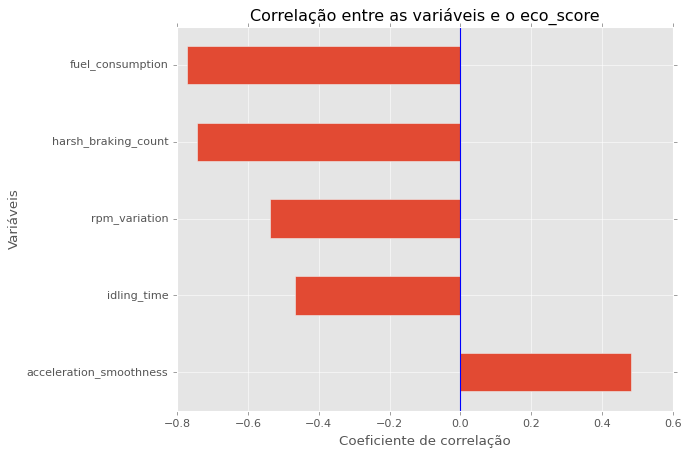

In [79]:
eco_score_correlation.drop('eco_score').plot(kind='barh')
plt.title('Correlação entre as variáveis e o eco_score')
plt.xlabel('Coeficiente de correlação')
plt.ylabel('Variáveis')
plt.axvline()
plt.show()

Com as correlações, o que pode ser observado é que o pior hábito entre os listados é a frenagem brusca, e o melhor é a suavidade nas acelerações do veículo.

#### 4.2 Criação de dados categóricos

Text(0.5, 0, 'eco_score')

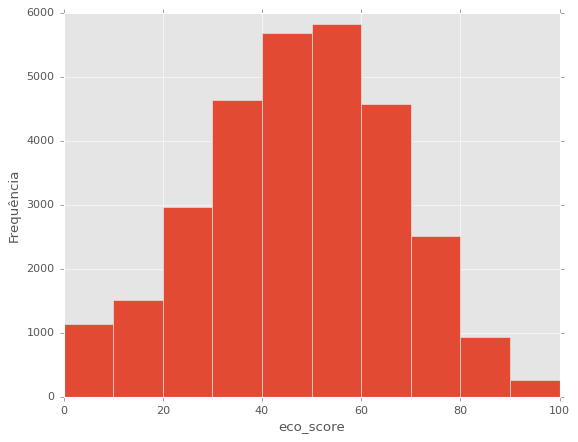

In [85]:
ax = df['eco_score'].plot.hist()
ax.set_ylabel('Frequência')
ax.set_xlabel('eco_score')

Text(0, 0.5, ' ')

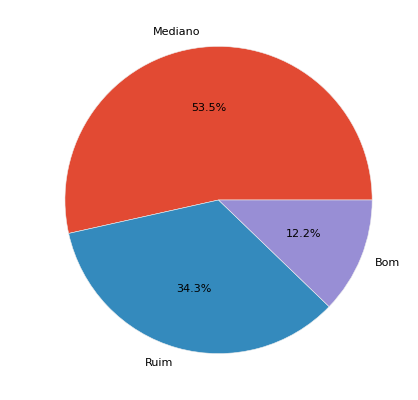

In [80]:
bins = [0, 40, 70, 100]
labels = ["Ruim", "Mediano", "Bom"]

df["eco_category"] = pd.cut(
    df["eco_score"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

ax = df['eco_category'].value_counts().plot.pie(autopct='%1.1f%%')
ax.set_ylabel(" ")

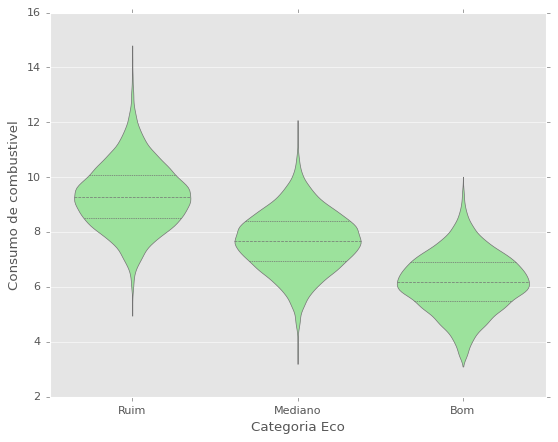

In [81]:
ax = sns.violinplot(x=df.eco_category, y=df.fuel_consumption, inner='quartile', color='lightgreen')
ax.set_xlabel('Categoria Eco')
ax.set_ylabel('Consumo de combustivel')
plt.show()


In [83]:
bom_mean = df.loc[df['eco_category'] == 'Bom']['fuel_consumption'].mean().round(2)
mediano_mean = df.loc[df['eco_category'] == 'Mediano']['fuel_consumption'].mean().round(2)
ruim_mean = df.loc[df['eco_category'] == 'Ruim']['fuel_consumption'].mean().round(2)

print(
f"""
Consumo máximo de combustível observado no dataset: {df['fuel_consumption'].max()}
Consumo médio de combustível por categoria
Ruim: {ruim_mean}
Mediano: {mediano_mean}
Bom: {bom_mean}
""")


Consumo máximo de combustível observado no dataset: 14.43
Consumo médio de combustível por categoria
Ruim: 9.31
Mediano: 7.67
Bom: 6.18



### 5. Conclusão

Motoristas classificados na categoria `Bom` apresentaram um consumo médio de combustível **19,4%** menor em relação aos motoristas da categoria `Mediano` e **33,6%** menor quando comparados aos da categoria `Ruim`

A análise de correlação indica que o hábito mais prejudicial à ecocondução é a **frenagem brusca** (−0,74), enquanto a **suavidade das acelerações** apresenta a correlação positiva mais elevada com o eco_score (0,48), caracterizando-se como o hábito mais benéfico para uma condução econômica e sustentável.